# Importance-Only Metrics

Сравнение classifier/detector метрик, которые считаются только по одному тензору важности. Для верхних долей важных нейронов строится sweep от 0.1% до 10.0%; отдельно считаются концентрация, энтропия, effective-neuron fraction и отношения хвостов распределения.


In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "ClassifierDetectorExperiments":
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "ClassifierDetectorExperiments"))

import side_by_side_analysis as sbs
importlib.reload(sbs)

compute_or_load_importance_only_tensor_metrics = sbs.compute_or_load_importance_only_tensor_metrics
plot_importance_only_percent_sweep = sbs.plot_importance_only_percent_sweep
plot_metric_leaderboards = sbs.plot_metric_leaderboards
plot_quality_metric_triplets = sbs.plot_quality_metric_triplets
save_tables = sbs.save_tables


In [2]:
FORCE = False
LAYER_NAME = "model.9"
TOP_PERCENTS = tuple(round(x / 10, 1) for x in range(1, 101))
MAX_EXAMPLES = None

result = compute_or_load_importance_only_tensor_metrics(
    REPO_ROOT,
    force=FORCE,
    layer_name=LAYER_NAME,
    top_percents=TOP_PERCENTS,
    max_examples=MAX_EXAMPLES,
)

roots = result["roots"]
rows = result["rows"].copy()
quality = result["quality"].copy()
regression = result["regression"].copy()

print("cache:", result["cache_path"])
print("loaded from cache:", result["loaded_from_cache"])
print("rows:", rows.shape)
print("quality:", quality.shape)
print("regression:", regression.shape)
print("output:", roots.comparison_output)
for warning in result.get("warnings", []):
    print("warning:", warning)

display(rows.groupby("source").size().rename("n_examples").reset_index())
display(quality.groupby(["source", "metric_family"]).size().rename("n_metrics").reset_index())


cache: /Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/cache/importance_only_tensor_metrics_090d40da9103a469.pkl
loaded from cache: True
rows: (11489, 814)
quality: (1414, 20)
regression: (1414, 13)
output: /Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs


,source,n_examples
0,classifier,5843
1,detector,5646


,source,metric_family,n_metrics
0,classifier,importance_concentration,5
1,classifier,importance_mass,102
2,classifier,importance_mean_unit,100
3,classifier,importance_min_unit,100
4,classifier,importance_psnr_mean,100
5,classifier,importance_psnr_min,100
6,classifier,importance_psnr_sum,100
7,classifier,importance_sum_unit,100
8,detector,importance_concentration,5
9,detector,importance_mass,102


In [3]:
quality_cols = [c for c in [
    "source", "experiment", "metric_family", "metric", "top_percent",
    "best_balanced_accuracy", "best_accuracy", "best_f1",
    "balanced_recall", "balanced_specificity", "roc_auc",
] if c in quality.columns]

regression_cols = [c for c in [
    "source", "experiment", "metric_family", "metric", "top_percent",
    "spearman", "pearson", "main_score", "n",
] if c in regression.columns]

display(
    quality[quality_cols]
    .sort_values(["best_balanced_accuracy", "best_f1"], ascending=False)
    .head(80)
)
display(
    regression[regression_cols]
    .sort_values("main_score", ascending=False)
    .head(80)
)


,source,experiment,metric_family,metric,top_percent,best_balanced_accuracy,best_accuracy,best_f1,balanced_recall,balanced_specificity,roc_auc
16,classifier,importance_only_tensor,importance_min_unit,importance_top0p2pct_min_unit,0.2,0.578506,0.734212,0.846526,0.662465,0.494548,0.406240
14,classifier,importance_only_tensor,importance_mass,importance_top0p2pct_mass_frac,0.2,0.572050,0.733185,0.846055,0.552054,0.592046,0.416554
9,classifier,importance_only_tensor,importance_min_unit,importance_top0p1pct_min_unit,0.1,0.570892,0.733356,0.846108,0.728058,0.413727,0.409676
18,classifier,importance_only_tensor,importance_psnr_sum,importance_psnr_top0p2pct_sum,0.2,0.568674,0.733527,0.846192,0.644725,0.492623,0.588348
19,classifier,importance_only_tensor,importance_psnr_mean,importance_psnr_top0p2pct_mean,0.2,0.568674,0.733527,0.846192,0.644725,0.492623,0.588348
...,...,...,...,...,...,...,...,...,...,...,...
434,classifier,importance_only_tensor,importance_mass,importance_top6p2pct_mass_frac,6.2,0.545170,0.733185,0.846055,0.327031,0.763310,0.526503
441,classifier,importance_only_tensor,importance_mass,importance_top6p3pct_mass_frac,6.3,0.545169,0.733185,0.846055,0.324463,0.765876,0.526541
581,classifier,importance_only_tensor,importance_mass,importance_top8p3pct_mass_frac,8.3,0.545168,0.733185,0.846055,0.321895,0.768441,0.526828
539,classifier,importance_only_tensor,importance_mass,importance_top7p7pct_mass_frac,7.7,0.545143,0.733185,0.846055,0.331466,0.758820,0.526909


,source,experiment,metric_family,metric,top_percent,spearman,pearson,main_score,n
16,classifier,importance_only_tensor,importance_min_unit,importance_top0p2pct_min_unit,0.2,-0.150146,-0.150198,0.150146,5843
14,classifier,importance_only_tensor,importance_mass,importance_top0p2pct_mass_frac,0.2,-0.150040,-0.106045,0.150040,5843
9,classifier,importance_only_tensor,importance_min_unit,importance_top0p1pct_min_unit,0.1,-0.142857,-0.144619,0.142857,5843
18,classifier,importance_only_tensor,importance_psnr_sum,importance_psnr_top0p2pct_sum,0.2,0.139868,0.126372,0.139868,5843
19,classifier,importance_only_tensor,importance_psnr_mean,importance_psnr_top0p2pct_mean,0.2,0.139868,0.126372,0.139868,5843
...,...,...,...,...,...,...,...,...,...
734,detector,importance_only_tensor,importance_psnr_min,importance_psnr_top0p3pct_min,0.3,-0.088439,-0.073325,0.088439,5646
1315,detector,importance_only_tensor,importance_psnr_min,importance_psnr_top8p6pct_min,8.6,-0.088439,-0.073325,0.088439,5646
741,detector,importance_only_tensor,importance_psnr_min,importance_psnr_top0p4pct_min,0.4,-0.088439,-0.073325,0.088439,5646
1308,detector,importance_only_tensor,importance_psnr_min,importance_psnr_top8p5pct_min,8.5,-0.088439,-0.073325,0.088439,5646


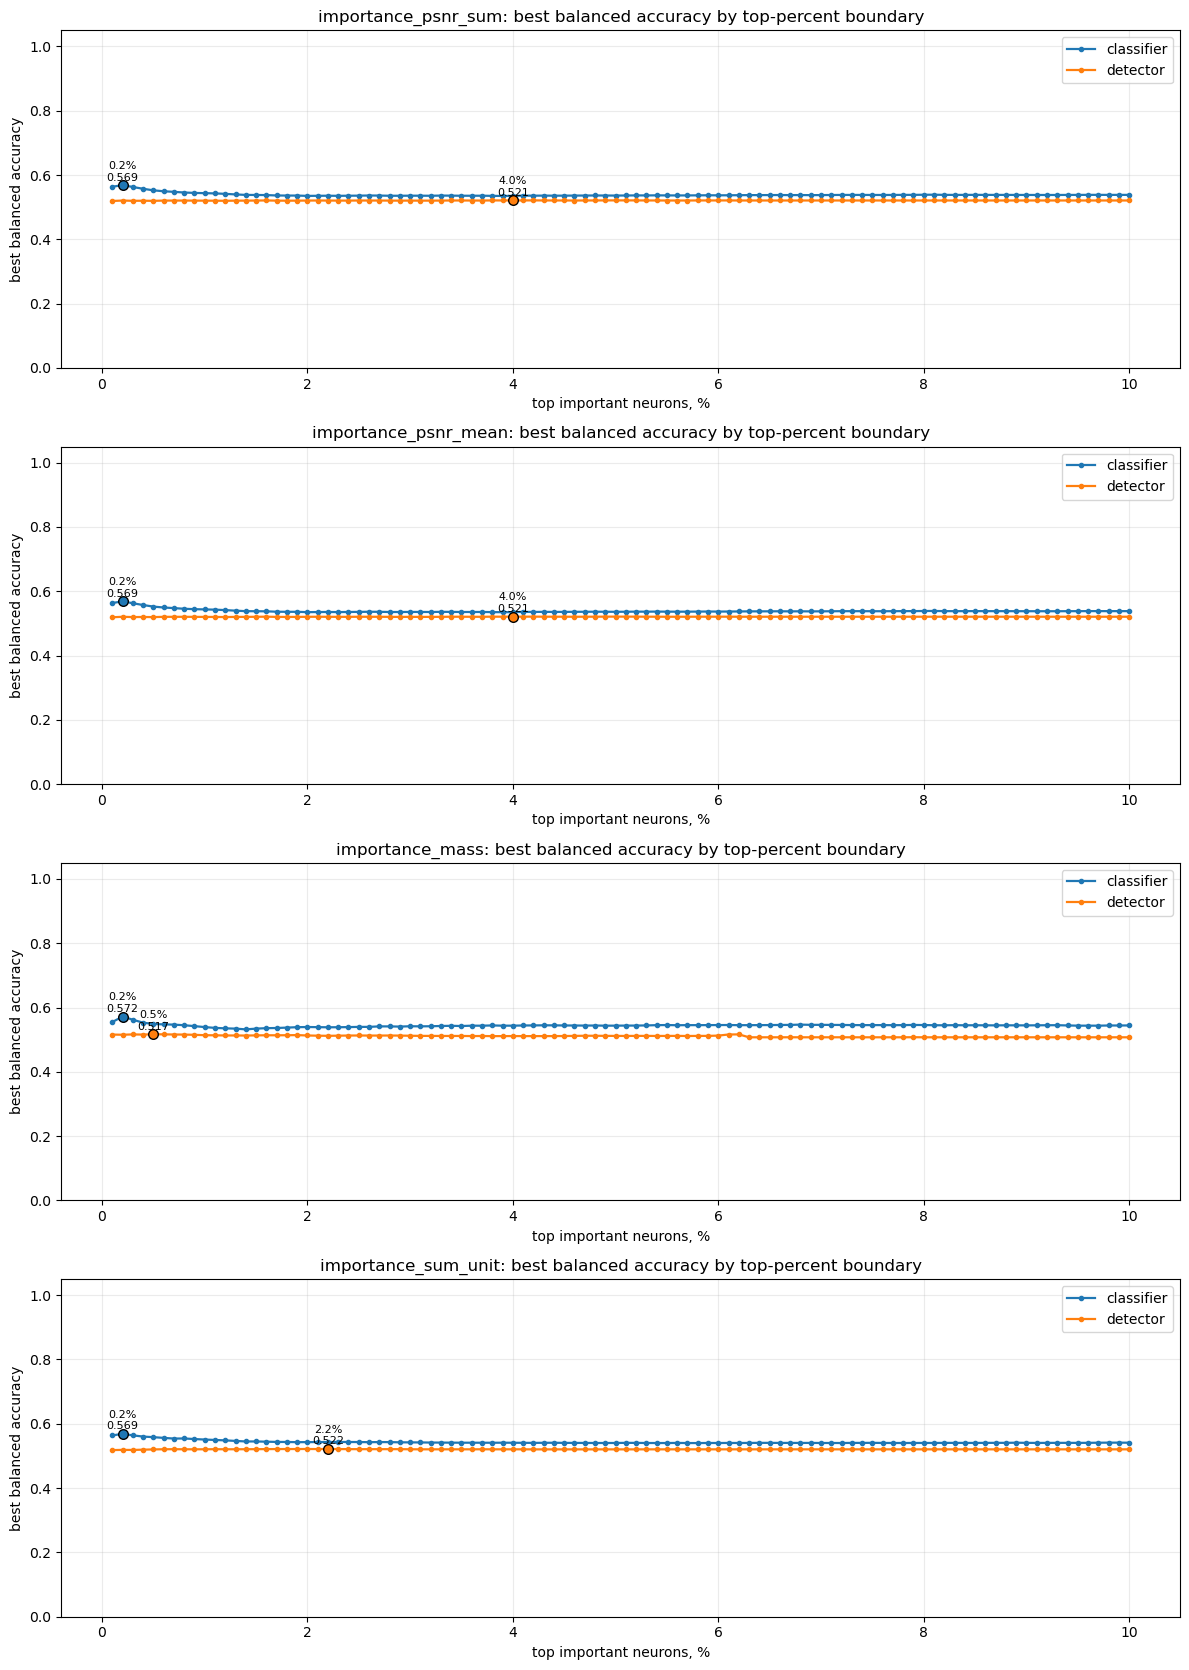

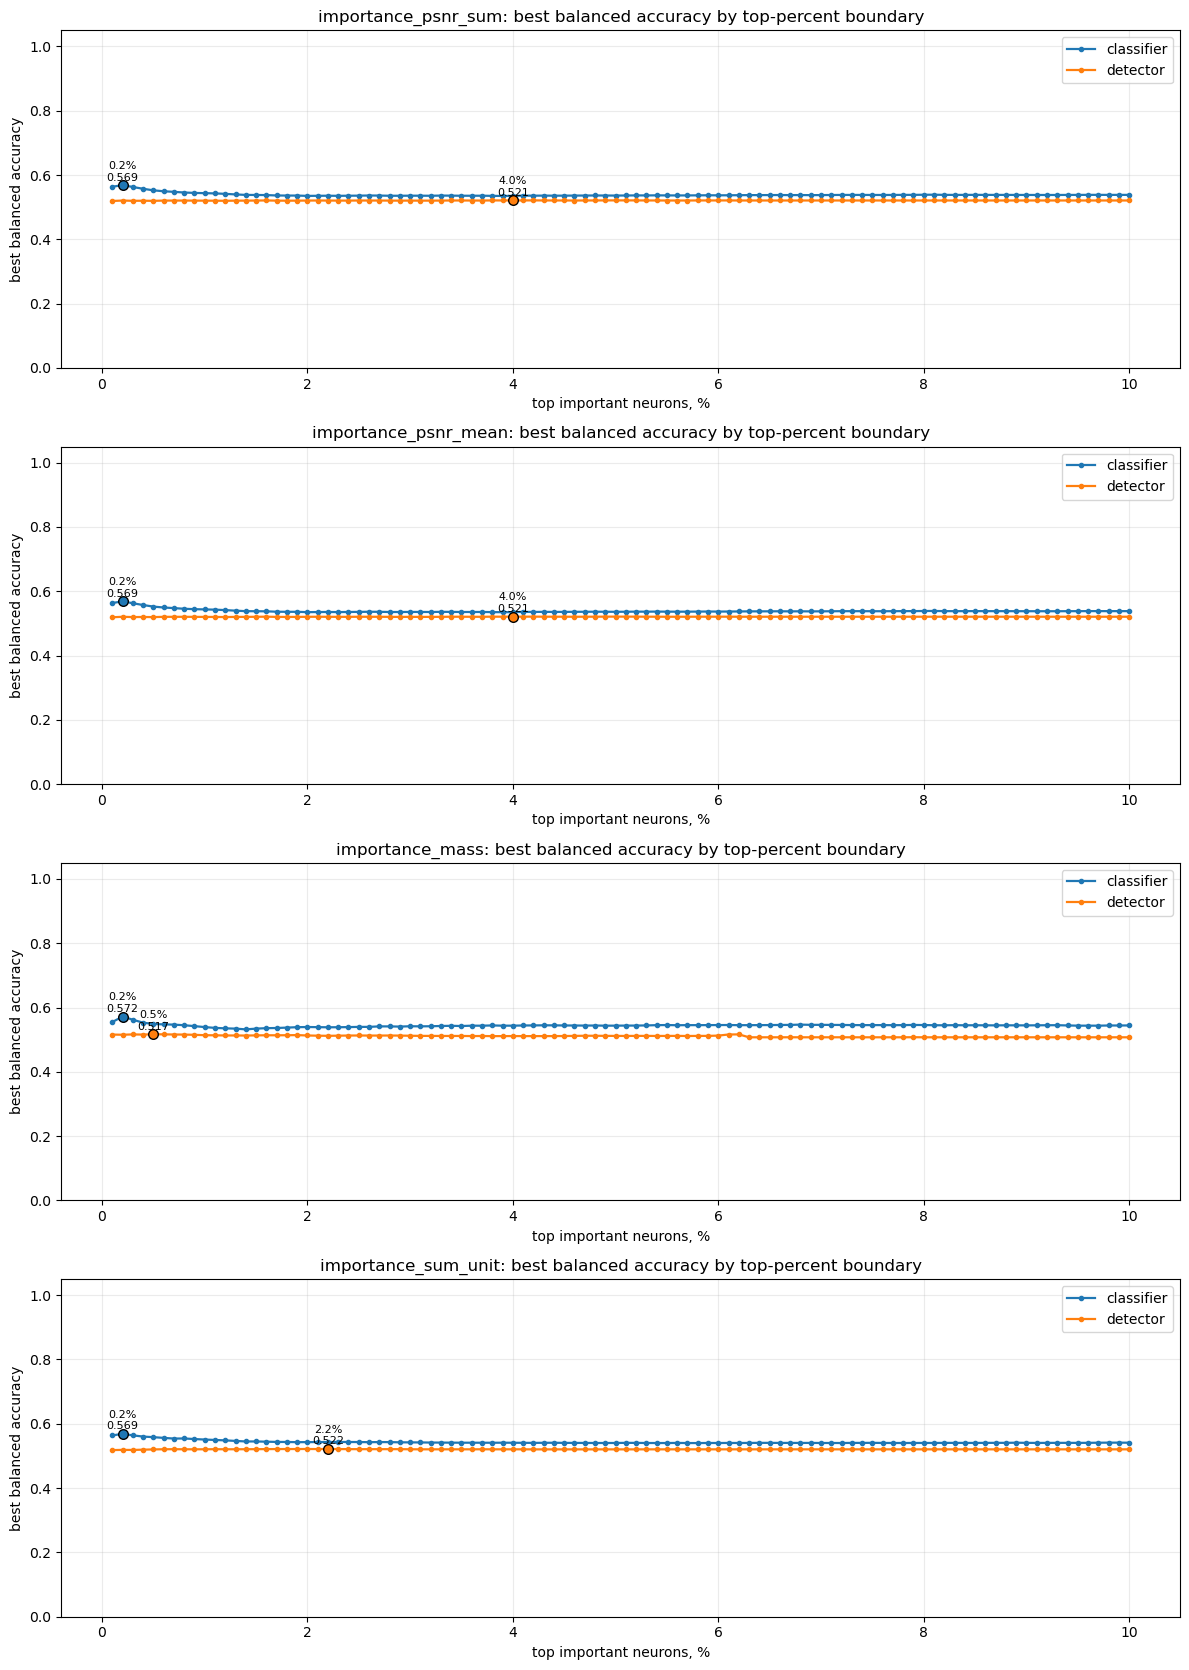

In [4]:
fig = plot_importance_only_percent_sweep(
    quality,
    metric_families=(
        "importance_psnr_sum",
        "importance_psnr_mean",
        "importance_mass",
        "importance_sum_unit",
    ),
)
fig.savefig(roots.comparison_output / "importance_only_percent_sweep.png", dpi=160, bbox_inches="tight")
fig


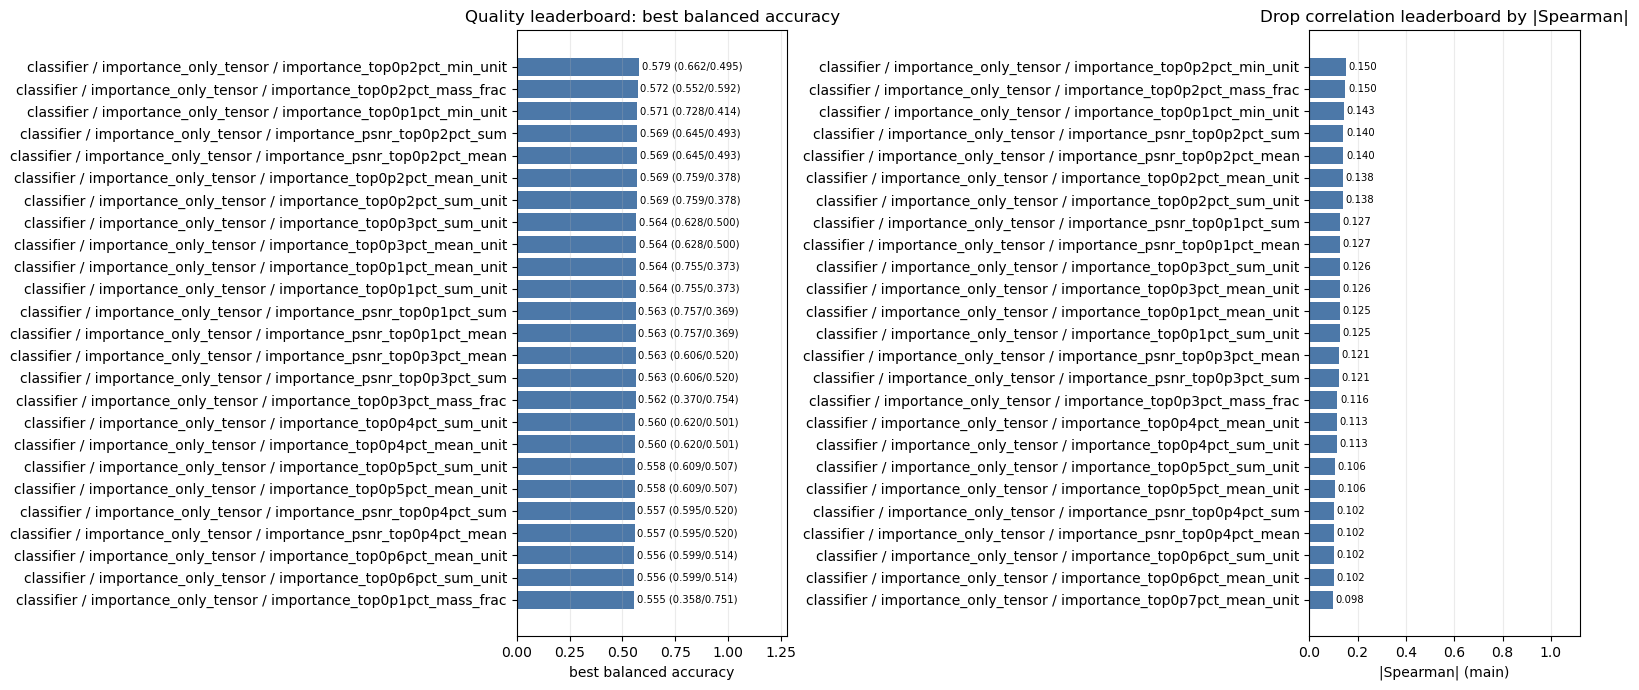

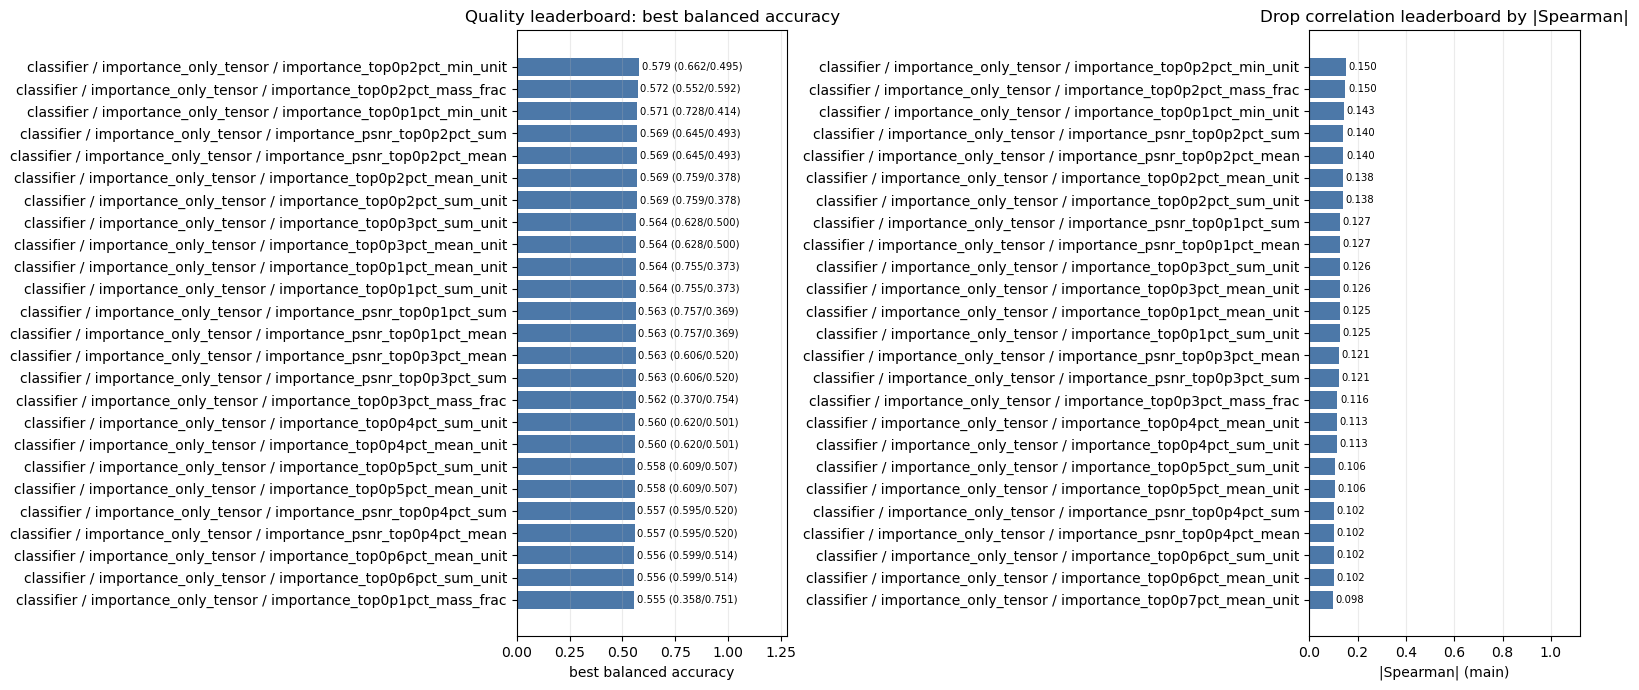

In [5]:
fig = plot_metric_leaderboards(quality, regression, top_n=25)
fig.savefig(roots.comparison_output / "importance_only_leaderboards.png", dpi=160, bbox_inches="tight")
fig


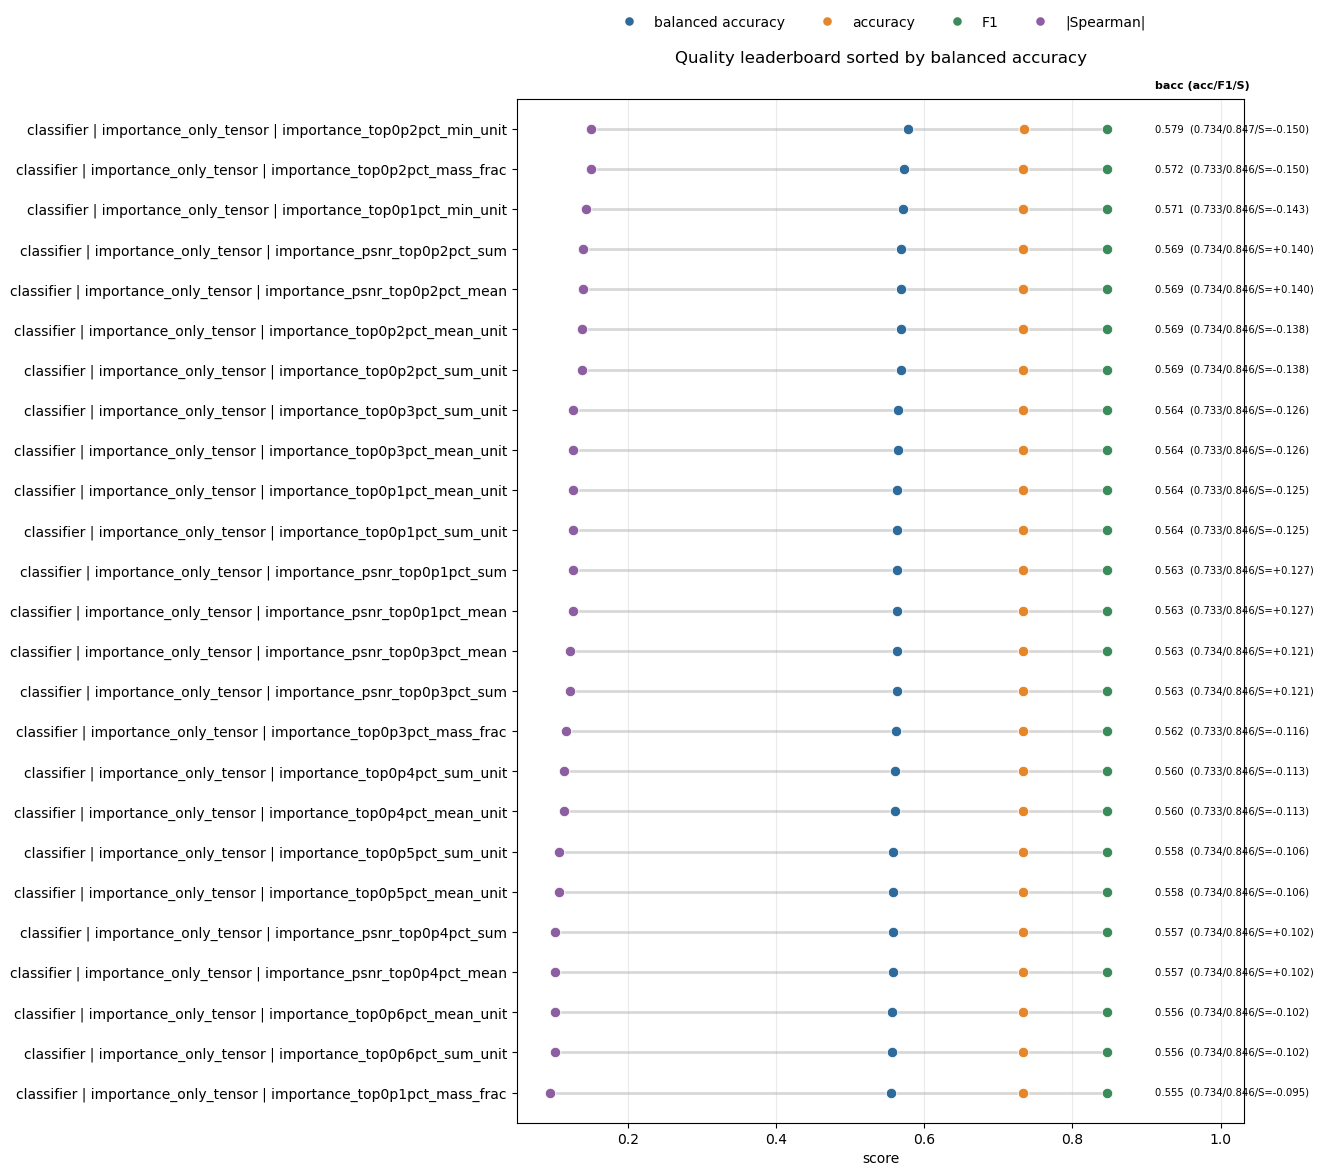

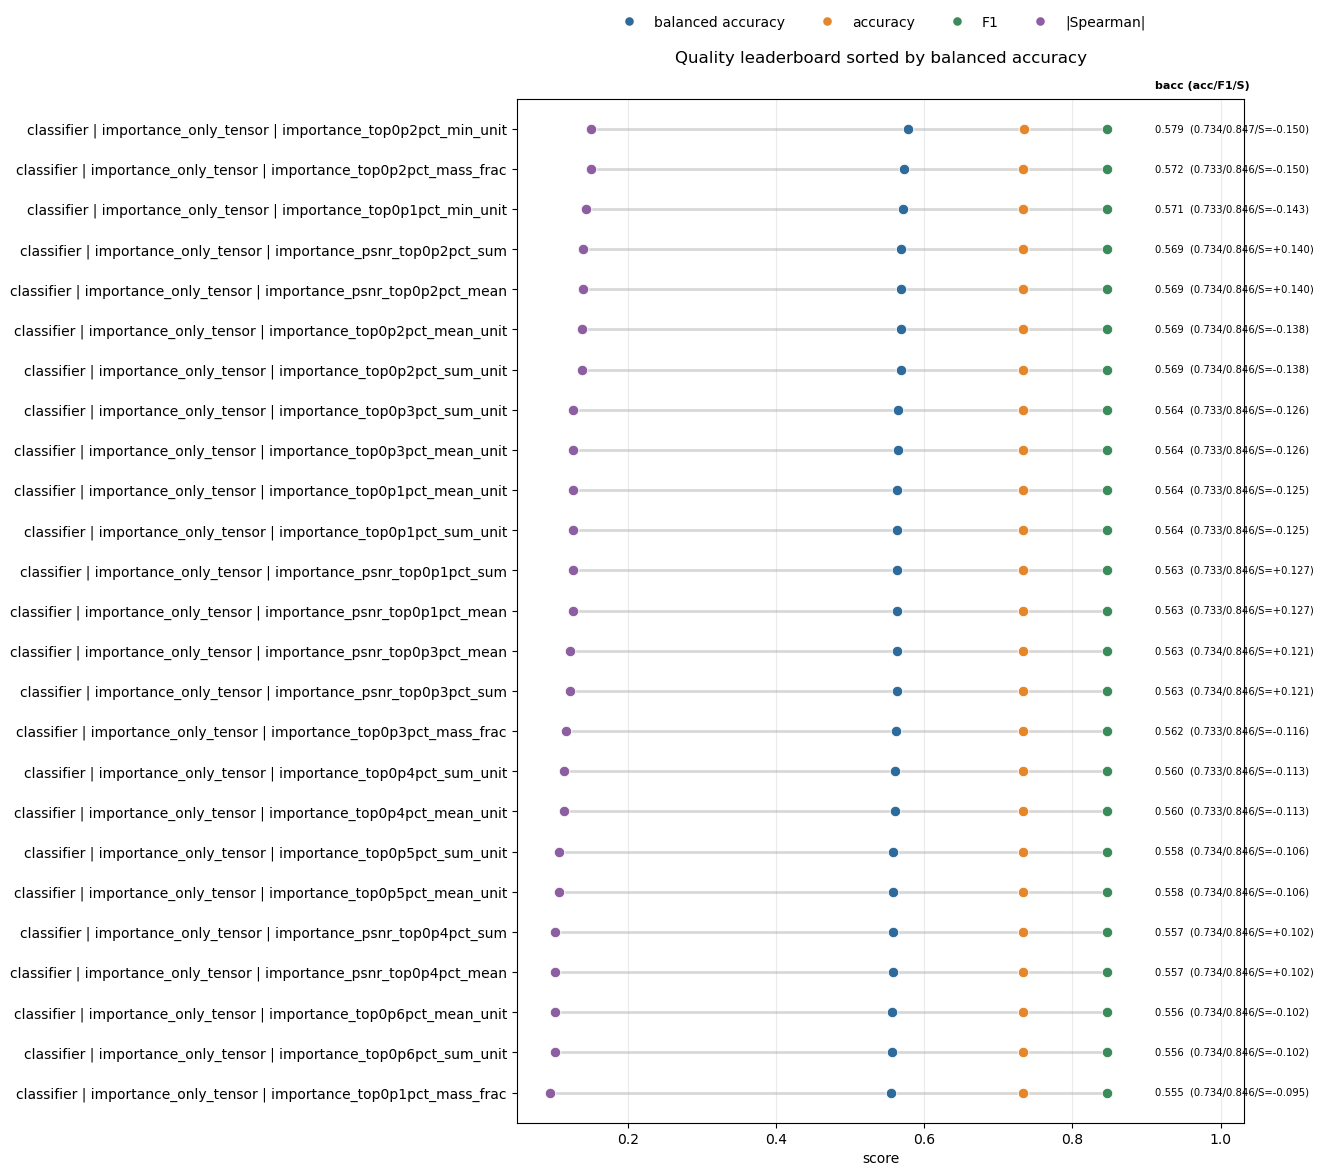

In [6]:
fig = plot_quality_metric_triplets(quality, regression, top_n=25)
fig.savefig(roots.comparison_output / "importance_only_quality_triplets.png", dpi=160, bbox_inches="tight")
fig


In [7]:
save_tables(
    {
        "importance_only_rows": rows,
        "importance_only_quality": quality,
        "importance_only_regression": regression,
    },
    roots.comparison_output,
    prefix="importance_only_tensor",
)

print("saved:")
print(roots.comparison_output / "importance_only_tensor_importance_only_rows.csv")
print(roots.comparison_output / "importance_only_tensor_importance_only_quality.csv")
print(roots.comparison_output / "importance_only_tensor_importance_only_regression.csv")


saved:
/Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/importance_only_tensor_importance_only_rows.csv
/Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/importance_only_tensor_importance_only_quality.csv
/Users/ashentide/PycharmProjects/PatchSuccessResearch/ClassifierDetectorExperiments/outputs/importance_only_tensor_importance_only_regression.csv
